In [1]:
pip install yfinance

   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.7 MB ? eta -:--:--
   ------ ------------------------


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [59]:
import yfinance as yf
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor



In [60]:
# Download Apple stock data
df = yf.download("AAPL", start="2020-01-01", end="2025-01-01")

# Keep required columns
df = df[['Open', 'High', 'Low', 'Close', 'Volume']]

print(df.head())

[*********************100%***********************]  1 of 1 completed

Price            Open       High        Low      Close     Volume
Ticker           AAPL       AAPL       AAPL       AAPL       AAPL
Date                                                             
2020-01-02  71.344039  72.394070  71.091169  72.333862  135480400
2020-01-03  71.563198  72.389250  71.406659  71.630630  146322800
2020-01-06  70.754021  72.239950  70.503554  72.201416  118387200
2020-01-07  72.211056  72.466338  71.642697  71.861855  108872000
2020-01-08  71.565644  73.318900  71.565644  73.017860  132079200


In [61]:
df['Target'] = df['Close'].shift(-1)
df = df.dropna()

print(df.head())

Price            Open       High        Low      Close     Volume     Target
Ticker           AAPL       AAPL       AAPL       AAPL       AAPL           
Date                                                                        
2020-01-02  71.344039  72.394070  71.091169  72.333862  135480400  71.630630
2020-01-03  71.563198  72.389250  71.406659  71.630630  146322800  72.201416
2020-01-06  70.754021  72.239950  70.503554  72.201416  118387200  71.861855
2020-01-07  72.211056  72.466338  71.642697  71.861855  108872000  73.017860
2020-01-08  71.565644  73.318900  71.565644  73.017860  132079200  74.568794


In [62]:
X = df[['Open', 'High', 'Low', 'Volume']]
y = df['Target']

In [63]:
# splitting data for training and teting 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [64]:
# train linear regression model on data
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](4,)","[ 0.33, 0.34, 0.33,-0. ]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,0.6083
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,2
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](4,)","[1.66e+09,1.77e+03,3.06e+01,2.93e+01]"


In [65]:
predictions = model.predict(X_test)

print(predictions[:5])

[143.27070471  77.46249985  60.006467    58.46756146 167.4304133 ]


In [66]:
# MAE and R2 of result
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("MAE:", mae)
print("R2 Score:", r2)

MAE: 2.2369847298353185
R2 Score: 0.9942324837367363


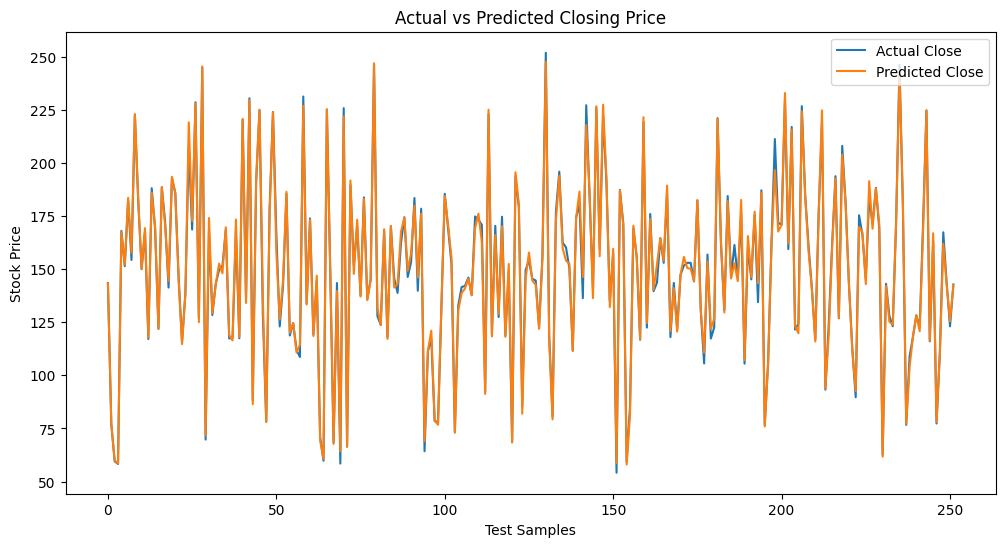

In [67]:
# viualization of actual and predicted result
plt.figure(figsize=(12,6))
plt.plot(y_test.values, label='Actual Close')
plt.plot(predictions, label='Predicted Close')
plt.legend()
plt.title("Actual vs Predicted Closing Price")
plt.xlabel("Test Samples")
plt.ylabel("Stock Price")
plt.show()

In [68]:
# RandomForestRegresso training on data
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
predictions = model.predict(X_test)

In [69]:
# MAE and R2 of result
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("MAE:", mae)
print("R2 Score:", r2)

MAE: 2.376202865782238
R2 Score: 0.994062191993983


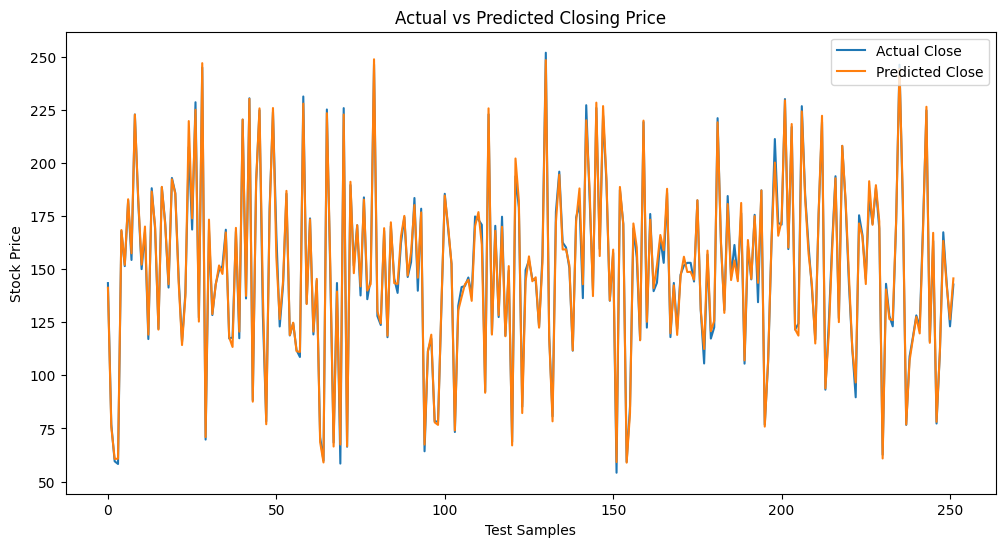

In [70]:
# viualization of actual and predicted result
plt.figure(figsize=(12,6))
plt.plot(y_test.values, label='Actual Close')
plt.plot(predictions, label='Predicted Close')
plt.legend()
plt.title("Actual vs Predicted Closing Price")
plt.xlabel("Test Samples")
plt.ylabel("Stock Price")
plt.show()